In [8]:
import numpy as np
import pandas
import scipy.sparse

import matplotlib.pyplot as plt

In [9]:
data = pandas.read_csv('../data/ml-latest-small/ratings.csv')

In [10]:
data

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [11]:
import sklearn

In [12]:
np.unique(data['userId']).shape

(610,)

In [14]:
np.unique(data['movieId'])

array([     1,      2,      3, ..., 193585, 193587, 193609], shape=(9724,))

In [15]:
R = scipy.sparse.coo_matrix(
    (data['rating'], (data['userId'] - 1, data['movieId'] - 1))
).tocsr()

In [16]:
R_train, R_test = sklearn.model_selection.train_test_split(R, test_size=0.2)

In [17]:
svd = sklearn.decomposition.TruncatedSVD(n_components=32, algorithm='randomized')

In [18]:
svd = svd.fit(R_train)

Z_train = svd.transform(R_train)
Z_test = svd.transform(R_test)

In [29]:
kdtree = sklearn.neighbors.KDTree(Z_train, metric='euclidean') 

In [34]:
kdtree.query(Z_test[:5], k=10)

(array([[ 2.30916598,  2.37388083,  2.74030176,  2.74832753,  2.83773918,
          2.8854862 ,  3.09652559,  3.27556869,  3.83314486,  3.99136641],
        [30.97566443, 31.88729869, 33.75860192, 34.23155814, 34.58545234,
         34.89199926, 34.94371994, 35.27865162, 35.56086548, 35.56108979],
        [ 4.92715038,  5.58132499,  6.72986281,  7.05508151,  7.13880875,
          7.23486761,  7.25156021,  7.29729674,  7.42381146,  7.56821103],
        [ 4.80563723,  5.34323153,  5.36164382,  5.42825189,  5.88070582,
          6.35169428,  6.44134527,  6.50670166,  6.58681943,  6.60363489],
        [ 4.20957772,  4.59347967,  4.78379204,  5.34914223,  5.37345186,
          5.45918236,  5.74977591,  6.08022809,  6.1597171 ,  6.6022007 ]]),
 array([[ 16, 158,  66,  17, 130, 422,  98, 305, 394, 444],
        [264,   6, 256, 320,  42, 485, 144, 307,  96,  75],
        [323, 405,  28, 396,  14, 439, 217, 280, 117, 255],
        [471, 363,  61,   2, 255, 191, 336, 364, 110,  18],
        [297,

In [31]:
R_train.shape, R_test.shape

((488, 193609), (122, 193609))

In [9]:
mean_R = R.sum(axis=1) / (R > 0).sum(axis=1)

In [10]:
S = sklearn.metrics.pairwise.cosine_similarity(R_test, R_train, dense_output=True)

In [11]:
S.shape

(122, 488)

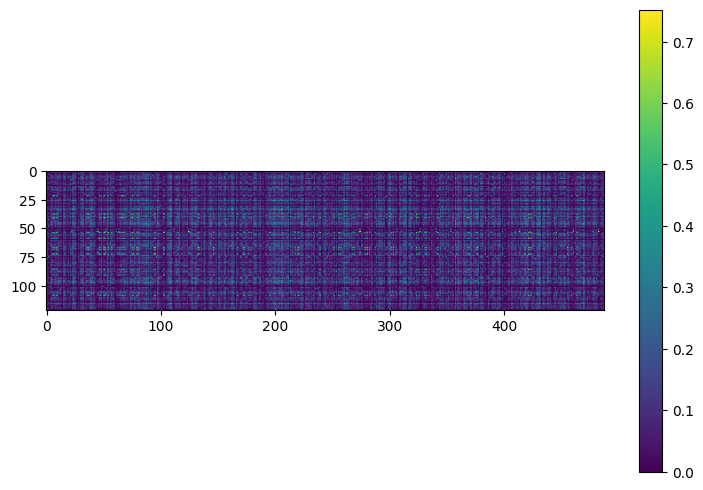

In [12]:
plt.figure(figsize=(9, 6))
plt.imshow(S)
plt.colorbar()

In [13]:
index = np.argsort(S, axis=1)

In [14]:
k = 10
neighbors = index[:, -k:]

In [15]:
neighbors_S = np.zeros(shape=neighbors.shape, dtype=float)
for i in range(S.shape[0]):
    neighbors_S[i, ] = S[i, neighbors[i]]

In [16]:
userId = 10
common_movies = {} 

for neighbor_index in neighbors[userId]:
    R_neighbor = R_train[neighbor_index]
    sim = S[userId, neighbor_index]
    for movieId, rating in zip(R_neighbor.indices, R_neighbor.data):
        if movieId not in common_movies:
            common_movies[movieId] = []

        common_movies[movieId].append((sim, rating))

(array([360.,  91.,  32.,  38.,   0.,  11.,   6.,   5.,   5.,   4.]),
 array([1. , 1.8, 2.6, 3.4, 4.2, 5. , 5.8, 6.6, 7.4, 8.2, 9. ]),
 <BarContainer object of 10 artists>)

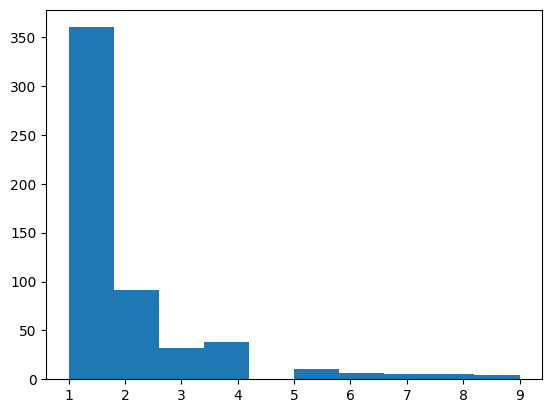

In [17]:
plt.hist([len(common_movies[mid]) for mid in common_movies])

In [18]:
recommendations = {}
for movieId in common_movies:
    recommendations[movieId] = sum(s * r for s, r in common_movies[movieId]) / sum(s for s, _ in common_movies[movieId])

In [19]:
movie_ids = np.array([mid for mid in recommendations.keys()])
predicted_ratings = np.array([float(x) for x in recommendations.values()])

In [20]:
sorted_indx = np.argsort(predicted_ratings)
best_recommendations = sorted_indx[-5:]

for best_i in best_recommendations:
    print(f'Movie: {movie_ids[best_i]}, predicted: {predicted_ratings[best_i]}')

Movie: 2010, predicted: 5.0
Movie: 1079, predicted: 5.0
Movie: 2077, predicted: 5.0
Movie: 8131, predicted: 5.0
Movie: 115148, predicted: 5.000000000000001


In [21]:
neighbors_S = S[np.arange(122)[:, None], neighbors]
neighbors_R = R[np.arange(122)[:, None], neighbors]